#### GRUPO DE DATOS - ESTUDIANTES ADMITIDOS SEGUN EL ESTRATO POR LA UNIVERSIDAD MILITAR NUEVA GRANADA DENTRO DEL RANGO (2016 - 2022)

Grupo de datos bajado de Datos Abiertos Colombia 

##### Preguntas
1. ¿ Cuantos estudiantes fueron admitidos de estratos bajos (0 - 3)?
2. ¿ Cantidad de estudiantes que se admitieron al programa de centro de idiomas - 2020 ? 
3. ¿ Cantidad de Estudiantes que fueron admitidos en el Area de posgrados en la región -  Campus ?

In [10]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Admitidos_Estrato_20260621.csv')
display(df.head(10))

df.info()

,Regional,Nivel,Programa,Total,Estrato,Ano,Periodo
0,Bogotá,COTERMINALES,ARTICULACIÓN ESP. EN PROCEDIMIENTO PENAL CONST...,1,3,2.022,2
1,Bogotá,COTERMINALES,COTERMINALES,1,1,2.022,2
2,Bogotá,COTERMINALES,COTERMINALES,2,2,2.022,2
3,Bogotá,COTERMINALES,COTERMINALES,1,3,2.022,2
4,Bogotá,COTERMINALES,COTERMINALES,10,3,2.022,2
5,Bogotá,COTERMINALES,COTERMINALES,2,4,2.022,2
6,Bogotá,COTERMINALES,COTERMINALES,1,N,2.022,2
7,Bogotá,CURSOS,CENTRO DE IDIOMAS (DISTANCIA),1,0,2.022,2
8,Bogotá,CURSOS,CENTRO DE IDIOMAS (DISTANCIA),2,1,2.022,2
9,Bogotá,CURSOS,CENTRO DE IDIOMAS (DISTANCIA),38,1,2.022,2


<class 'pandas.DataFrame'>
RangeIndex: 16285 entries, 0 to 16284
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Regional  16285 non-null  str    
 1   Nivel     16285 non-null  str    
 2   Programa  16285 non-null  str    
 3   Total     16285 non-null  int64  
 4   Estrato   16285 non-null  str    
 5   Ano       16285 non-null  float64
 6   Periodo   16285 non-null  int64  
dtypes: float64(1), int64(2), str(4)
memory usage: 890.7 KB


##### Limpieza de datos 
1. replace en la columna Estrato al cambiar N por datos desconocidos, para mejorar su interpretacion
2. Multiplicacion para correcion del año. Identificaba la fecha de forma complicada, se multiplico por 1000 para que tome los años de forma correcta

In [2]:
df['Estrato'] = df['Estrato'].str.replace('N','Desconocido',regex=False)

df['Ano'] = df['Ano'] * 1000

display(df.head(10))


,Regional,Nivel,Programa,Total,Estrato,Ano,Periodo
0,Bogotá,COTERMINALES,ARTICULACIÓN ESP. EN PROCEDIMIENTO PENAL CONST...,1,3,2022.0,2
1,Bogotá,COTERMINALES,COTERMINALES,1,1,2022.0,2
2,Bogotá,COTERMINALES,COTERMINALES,2,2,2022.0,2
3,Bogotá,COTERMINALES,COTERMINALES,1,3,2022.0,2
4,Bogotá,COTERMINALES,COTERMINALES,10,3,2022.0,2
5,Bogotá,COTERMINALES,COTERMINALES,2,4,2022.0,2
6,Bogotá,COTERMINALES,COTERMINALES,1,Desconocido,2022.0,2
7,Bogotá,CURSOS,CENTRO DE IDIOMAS (DISTANCIA),1,0,2022.0,2
8,Bogotá,CURSOS,CENTRO DE IDIOMAS (DISTANCIA),2,1,2022.0,2
9,Bogotá,CURSOS,CENTRO DE IDIOMAS (DISTANCIA),38,1,2022.0,2


##### Se identifico lo siguiente 
1. al entrar en cuestion fechas como pandemia, se reconocio un pico de ingreso de estratos 2 y 3, lo que genero que en otros apartados el ingreso de estudiantes no fuera tan significante
2. El ingreso lodico fue en el apartado de Pregrado, pero en el programa de Tecnologos se noto una gran diferencia con respecto a otros años y en ese año hubo un incremento como se puede evidenciar 

In [ ]:
estratos_validos = ['0', '1', '2', '3']
estratos_ = ['2']

df_filtrado = df[(df['Estrato'].isin(estratos_validos)) & (df['Nivel'] == 'TECNOLOGIA')]
df_filtrado_1 = df[(df['Ano'] == 2020) & (df['Nivel'] == 'TECNOLOGIA') & (df['Estrato'].isin(estratos_))]

total_estratos = df_filtrado['Total'].sum()
total_estratos_max = df_filtrado['Total'].max()

total_estratos1 = df_filtrado_1['Total'].sum()
prom_tec = df_filtrado_1.groupby('Periodo')['Total'].sum()
prom_tec1 = df_filtrado_1.groupby('Estrato')['Total'].mean()


display(f" La cantidad de estudiantes que ingresaron en el 2020 segun el periodo ", prom_tec)
display(f" El Total de estudiantes que entraron al programa de tecnologia {total_estratos} y el numero maximo que entraron segun el registro es de {total_estratos_max}")
print(f" El promedio de estudiantes que entraron en el año 2020, que sean de estrato 2 es de: {prom_tec1}")
display(prom_tec1)



' La cantidad de estudiantes que ingresaron en el 2020 segun el periodo '

Periodo
1    132
2    114
Name: Total, dtype: int64

' El Total de estudiantes que entraron al programa de tecnologia 2895 y el numero maximo que entraron segun el registro es de 32'

 El promedio de estudiantes que entraron en el año 2020, que sean de estrato 2 es de: 


Estrato
2    9.461538
Name: Total, dtype: float64

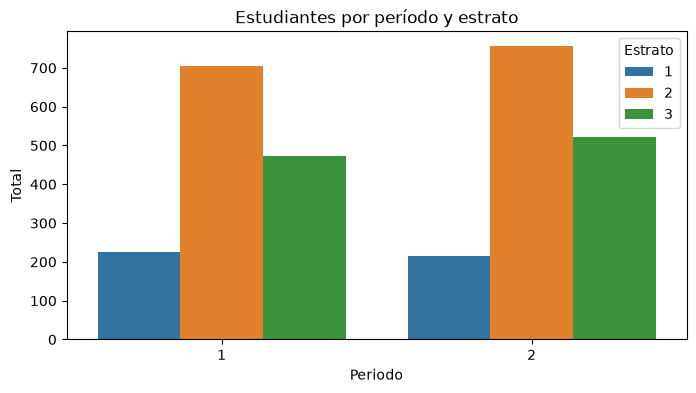

In [17]:
tabla = df_filtrado.groupby(['Periodo','Estrato'])['Total'].sum().reset_index()

plt.figure(figsize=(8,4))

sns.barplot(
    data=tabla,
    x='Periodo',
    y='Total',
    hue='Estrato'
)

plt.title('Estudiantes por período y estrato')
plt.show()

In [8]:
df_idiomas = df[(df['Programa'] == 'CENTRO DE IDIOMAS (DISTANCIA)') & (df['Ano'] == 2020 )]
df_idiomas1 = df[(df['Programa'] == 'CENTRO DE IDIOMAS (DISTANCIA)') & (df['Ano'] == 2020 ) & (df['Estrato'] == '2')]

total_idiomas = df_idiomas['Total'].sum()
total_idiomas1 = df_idiomas['Total'].mean()

prom = df_idiomas1.groupby('Estrato')['Total'].mean()
display(prom)

display(f" el Total de estudiantes que entraron en el año de pandemia fue de {total_idiomas}")
display(f" El promedio de estudiantes que entraron en pandemia y que sean de estrato 2 fue de : {total_idiomas1}")

Estrato
2    101.125
Name: Total, dtype: float64

' el Total de estudiantes que entraron en el año de pandemia fue de 2286'

' El promedio de estudiantes que entraron en pandemia y que sean de estrato 2 fue de : 48.638297872340424'

In [5]:
df_area = df[(df['Nivel'] == 'POSGRADO') & (df['Regional'] == 'Campus Nueva Granada') & (df['Ano'] == 2020)]

df_Tot_area = df_area['Total'].sum()

df_Nivel = df.groupby('Regional')['Total'].count()
display(df_Nivel)

display(f"El total de posgrados en la region de Campus fue de : {df_Tot_area} estudiantes")

Regional
Bogotá                  10189
Campus Nueva Granada     6096
Name: Total, dtype: int64

'El total de posgrados en la region de Campus fue de : 490 estudiantes'